In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from dotenv import load_dotenv

from mp_api.client import MPRester
from pymatgen.core import Element

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [31]:
load_dotenv()
API_KEY = os.getenv("MY_API_KEY")

In [32]:
with MPRester(API_KEY) as m:
   docs = m.summary.search(
    num_elements=2,
    fields=[
        "material_id", 
        "formula_pretty",
        "elements", 
        "nelements",
        "formation_energy_per_atom",
        "energy_above_hull",
        "is_stable",
        "symmetry",
        "composition_reduced"
        ]
   )

print(f"Found {len(docs)} entries for Fe-based alloys.")
print(docs[0])

/var/folders/7b/l4bd8yf50b9_zt4ms77_l52w0000gn/T/ipykernel_16283/1989659453.py:2: DeprecationWarning: Accessing summary data through MPRester.summary is deprecated. Please use MPRester.materials.summary instead.
  docs = m.summary.search(


Retrieving SummaryDoc documents:   0%|          | 0/20765 [00:00<?, ?it/s]

Found 20765 entries for Fe-based alloys.
MPDataDoc<_DictLikeAccess>
elements=[Element Ac, Element Mg],
nelements=2,
composition_reduced=Composition('Ac2 Mg1'),
formula_pretty='Ac2Mg',
symmetry=SymmetryData(crystal_system=<CrystalSystem.ortho: 'Orthorhombic'>, symbol='Cmcm', hall=None, number=63, point_group='mmm', symprec=0.1, angle_tolerance=5.0, version='2.5.0'),
material_id=MPID(mp-1183085),
formation_energy_per_atom=-0.006879308333334001,
energy_above_hull=0.033049974166663006,
is_stable=False

Fields not requested:
['builder_meta', 'nsites', 'composition', 'formula_anonymous', 'chemsys', 'volume', 'density', 'density_atomic', 'deprecated', 'deprecation_reasons', 'last_updated', 'origins', 'warnings', 'structure', 'property_name', 'task_ids', 'uncorrected_energy_per_atom', 'energy_per_atom', 'equilibrium_reaction_energy_per_atom', 'decomposes_to', 'xas', 'grain_boundaries', 'band_gap', 'cbm', 'vbm', 'efermi', 'is_gap_direct', 'is_metal', 'es_source_calc_id', 'bandstructure', 'dos',

In [33]:
rows = []
for d in docs:
    rows.append({
        "material_id": d.material_id,
        "formula": d.formula_pretty,
        "elements": [str(el) for el in d.elements],
        "nelements": d.nelements,
        "formation_energy_per_atom": d.formation_energy_per_atom,
        "energy_above_hull": d.energy_above_hull,
        "is_stable": d.is_stable,
        "symmetry": d.symmetry,
    })
    
df = pd.DataFrame(rows)
print(f"DataFrame created with {len(df)} rows and {len(df.columns)} columns.")
print(df.head())

DataFrame created with 20765 rows and 8 columns.
  material_id formula  elements  nelements  formation_energy_per_atom  \
0  mp-1183085   Ac2Mg  [Ac, Mg]          2                  -0.006879   
1  mp-1183089   Ac2Mg  [Ac, Mg]          2                  -0.019751   
2   mp-985286   Ac2Mg  [Ac, Mg]          2                  -0.006999   
3    mp-11107   Ac2O3   [Ac, O]          2                  -3.737668   
4    mp-32800   Ac2S3   [Ac, S]          2                  -2.493064   

   energy_above_hull  is_stable  \
0           0.033050      False   
1           0.020178      False   
2           0.032931      False   
3           0.000000       True   
4           0.000000       True   

                                            symmetry  
0  crystal_system=<CrystalSystem.ortho: 'Orthorho...  
1  crystal_system=<CrystalSystem.mono: 'Monoclini...  
2  crystal_system=<CrystalSystem.tet: 'Tetragonal...  
3  crystal_system=<CrystalSystem.trig: 'Trigonal'...  
4  crystal_system=<Crystal

In [34]:
from pymatgen.core import Element

def is_metal_pair(elements):
    return all(Element(el).is_metal for el in elements)

df=df[df["elements"].apply(is_metal_pair)].copy()
print(f"Filtered to {len(df)} binary metal alloys.")

Filtered to 9360 binary metal alloys.


In [35]:
df["pair"]=df["elements"].apply(lambda x: "-".join(sorted(x)))
pair_df = df.groupby("pair").agg(
    min_e_above_hull=("energy_above_hull", "min"),
    min_formation_energy=("formation_energy_per_atom", "min"),
    n_entries=("material_id", "count"),
    any_stable=("is_stable", "max")
).reset_index()
print("Total alloy pairs:", len(pair_df))
pair_df

Total alloy pairs: 1867


,pair,min_e_above_hull,min_formation_energy,n_entries,any_stable
0,Ac-Ag,0.000000,-0.271157,4,True
1,Ac-Al,0.000000,-0.408916,1,True
2,Ac-Au,0.000000,-0.771292,2,True
3,Ac-Ba,0.104439,0.104439,3,False
4,Ac-Ca,0.027833,0.027833,2,False
...,...,...,...,...,...
1862,Y-Zn,0.000000,-0.400875,13,True
1863,Y-Zr,0.112601,0.112601,1,False
1864,Yb-Zn,0.000000,-0.448140,3,True
1865,Yb-Zr,0.019923,0.019923,2,False


In [36]:
#Features
from pymatgen.core import Element

def get_features(pair):
    A,B=pair.split("-")
    el1,el2=Element(A),Element(B)

    return {
        "pair":pair,

        #atomic number
        "Z_avg":(el1.Z+el2.Z)/2,
        "Z_diff":abs(el1.Z-el2.Z),
        #atomic radius
        "r_avg":(el1.atomic_radius+el2.atomic_radius)/2,
        "r_diff":abs(el1.atomic_radius-el2.atomic_radius),
        #electronegativity
        "EN_avg":(el1.X+el2.X)/2,
        "EN_diff":abs(el1.X-el2.X),
        # periodic trends
        "same_group": int(el1.group==el2.group),
        "same_block": int(el1.block==el2.block),
    }

features_df = pd.DataFrame([get_features(pair) for pair in pair_df["pair"]])
features_df

,pair,Z_avg,Z_diff,r_avg,r_diff,EN_avg,EN_diff,same_group,same_block
0,Ac-Ag,68.0,42,1.775,0.35,1.515,0.83,0,0
1,Ac-Al,51.0,76,1.600,0.70,1.355,0.51,0,0
2,Ac-Au,84.0,10,1.650,0.60,1.820,1.44,0,0
3,Ac-Ba,72.5,33,2.050,0.20,0.995,0.21,0,0
4,Ac-Ca,54.5,69,1.875,0.15,1.050,0.10,0,0
...,...,...,...,...,...,...,...,...,...
1862,Y-Zn,34.5,9,1.575,0.45,1.435,0.43,0,1
1863,Y-Zr,39.5,1,1.675,0.25,1.275,0.11,0,1
1864,Yb-Zn,50.0,40,1.550,0.40,1.375,0.55,0,0
1865,Yb-Zr,55.0,30,1.650,0.20,1.215,0.23,0,0


In [37]:
final_df = pair_df.merge(features_df, on="pair")
final_df.head()

,pair,min_e_above_hull,min_formation_energy,n_entries,any_stable,Z_avg,Z_diff,r_avg,r_diff,EN_avg,EN_diff,same_group,same_block
0,Ac-Ag,0.000000,-0.271157,4,True,68.0,42,1.775,0.35,1.515,0.83,0,0
1,Ac-Al,0.000000,-0.408916,1,True,51.0,76,1.600,0.70,1.355,0.51,0,0
2,Ac-Au,0.000000,-0.771292,2,True,84.0,10,1.650,0.60,1.820,1.44,0,0
3,Ac-Ba,0.104439,0.104439,3,False,72.5,33,2.050,0.20,0.995,0.21,0,0
4,Ac-Ca,0.027833,0.027833,2,False,54.5,69,1.875,0.15,1.050,0.10,0,0


In [38]:
final_df["radius_mismatch_pct"] = final_df["r_diff"] / final_df["r_avg"]
final_df.groupby("any_stable")["radius_mismatch_pct"].mean()

any_stable
False    0.164326
True     0.189245
Name: radius_mismatch_pct, dtype: float64

In [39]:
final_df.groupby("any_stable")["EN_diff"].mean()

any_stable
False    0.350069
True     0.641381
Name: EN_diff, dtype: float64

In [40]:
from sklearn.ensemble import RandomForestClassifier

X = final_df[["r_diff", "EN_diff", "Z_diff"]].dropna()
y = final_df.loc[X.index, "any_stable"]

model = RandomForestClassifier()
model.fit(X, y)

print(model.feature_importances_)

[0.18973592 0.50246887 0.30779521]


In [41]:
final_df.describe()

,min_e_above_hull,min_formation_energy,n_entries,Z_avg,Z_diff,r_avg,r_diff,EN_avg,EN_diff,same_group,same_block,radius_mismatch_pct
count,1867.000000,1867.000000,1867.000000,1867.000000,1867.000000,1867.000000,1867.000000,1867.000000,1867.000000,1867.000000,1867.000000,1867.000000
mean,0.132076,-0.081828,5.013390,52.163899,28.434922,1.619845,0.292394,1.532255,0.505945,0.145688,0.324585,0.177660
std,0.253424,0.458707,6.849346,17.323522,20.131279,0.198807,0.238174,0.315017,0.370573,0.352888,0.468345,0.137659
min,0.000000,-1.464130,1.000000,3.500000,1.000000,1.150000,0.000000,0.805000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,-0.355805,2.000000,40.000000,12.000000,1.475000,0.100000,1.290000,0.200000,0.000000,0.000000,0.055556
50%,0.000000,-0.043228,3.000000,52.500000,25.000000,1.600000,0.250000,1.530000,0.430000,0.000000,0.000000,0.153846
75%,0.154468,0.152561,6.000000,65.000000,42.000000,1.750000,0.450000,1.750000,0.745000,0.000000,1.000000,0.276923
max,1.624576,1.624576,88.000000,93.500000,91.000000,2.475000,1.350000,2.450000,1.750000,1.000000,1.000000,0.707692


In [42]:
final_df.groupby("any_stable")[[
    "r_diff", "EN_diff", "Z_diff"
]].mean()

,r_diff,EN_diff,Z_diff
any_stable,,,
False,0.283583,0.350069,28.615207
True,0.300050,0.641381,28.278278


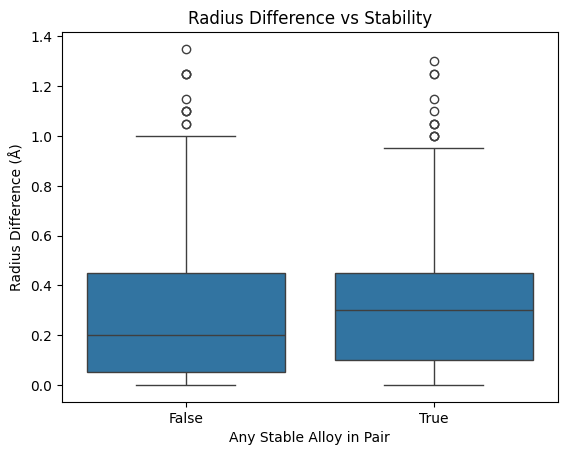

In [43]:
sns.boxplot(x="any_stable", y="r_diff", data=final_df)
plt.title("Radius Difference vs Stability")
plt.xlabel("Any Stable Alloy in Pair")
plt.ylabel("Radius Difference (Å)")
plt.show()

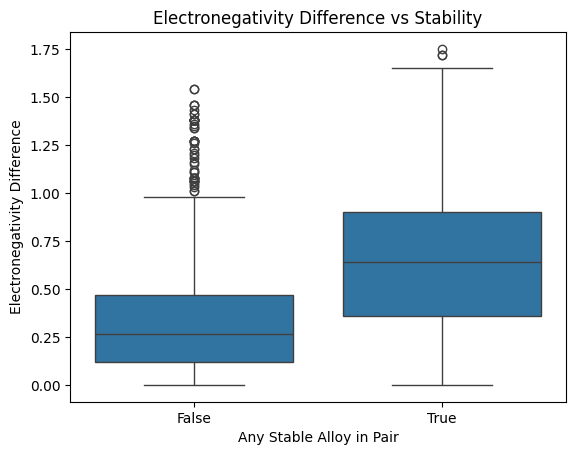

In [44]:
sns.boxplot(x="any_stable", y="EN_diff", data=final_df)
plt.title("Electronegativity Difference vs Stability")
plt.xlabel("Any Stable Alloy in Pair")
plt.ylabel("Electronegativity Difference")
plt.show()

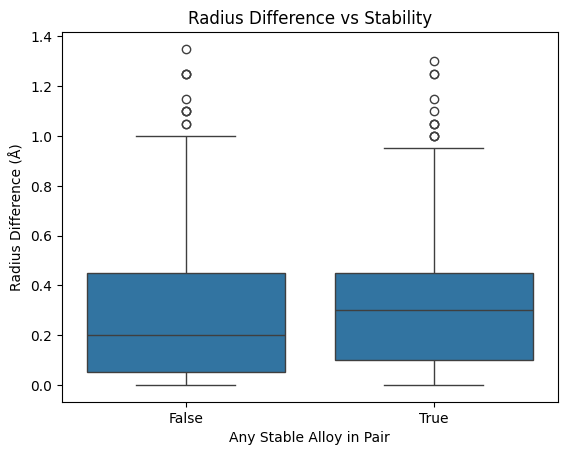

In [45]:
sns.boxplot(x="any_stable", y="r_diff", data=final_df)
plt.title("Radius Difference vs Stability")
plt.xlabel("Any Stable Alloy in Pair")
plt.ylabel("Radius Difference (Å)")
plt.show()